In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "No GPU detectada")

Sun Apr 26 22:49:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

import numpy as np
from numba import cuda

print("CUDA disponible:", cuda.is_available())
print("GPU:", cuda.get_current_device().name)

CUDA disponible: True
GPU: Tesla T4


In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nPrecisión en test: {acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9107 - loss: 0.3166 - val_accuracy: 0.9607 - val_loss: 0.1459
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9586 - loss: 0.1418 - val_accuracy: 0.9732 - val_loss: 0.1002
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9712 - loss: 0.0983 - val_accuracy: 0.9742 - val_loss: 0.0890
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9782 - loss: 0.0745 - val_accuracy: 0.9750 - val_loss: 0.0831
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9827 - loss: 0.0584 - val_accuracy: 0.9772 - val_loss: 0.0839

Precisión en test: 0.9742


In [4]:
W1, b1 = model.layers[1].get_weights()
W2, b2 = model.layers[2].get_weights()

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 128)
b1: (128,)
W2: (128, 10)
b2: (10,)


In [5]:
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1
from numba import cuda
import numpy as np

@cuda.jit
def relu_kernel(x, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        out[i] = max(0.0, x[i])

@cuda.jit
def matmul_bias_kernel(x, W, b, out):
    i = cuda.grid(1)
    if i < out.shape[0]:
        s = 0.0
        for j in range(x.shape[0]):
            s += x[j] * W[j, i]
        out[i] = s + b[i]

@cuda.jit
def softmax_exp_kernel(x, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        out[i] = cuda.libdevice.expf(x[i])

print("Kernels definidos correctamente.")

Kernels definidos correctamente.


In [6]:
def forward_pass(imagen):
    x = imagen.flatten().astype(np.float32)

    threads = 128

    z1 = np.zeros(128, dtype=np.float32)
    blocks = (128 + threads - 1) // threads
    matmul_bias_kernel[blocks, threads](x, W1.astype(np.float32), b1.astype(np.float32), z1)
    cuda.synchronize()

    a1 = np.zeros(128, dtype=np.float32)
    relu_kernel[blocks, threads](z1, a1)
    cuda.synchronize()

    z2 = np.zeros(10, dtype=np.float32)
    blocks2 = (10 + threads - 1) // threads
    matmul_bias_kernel[blocks2, threads](a1, W2.astype(np.float32), b2.astype(np.float32), z2)
    cuda.synchronize()

    exp_z2 = np.zeros(10, dtype=np.float32)
    softmax_exp_kernel[blocks2, threads](z2, exp_z2)
    cuda.synchronize()
    probs = exp_z2 / exp_z2.sum()

    return probs

print("Forward pass definido.")

Forward pass definido.


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:934: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:934: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanc

Real: 3 | Predicción: 3 | Confianza: 0.9989 | ✅
Real: 3 | Predicción: 3 | Confianza: 0.9999 | ✅
Real: 5 | Predicción: 5 | Confianza: 0.9999 | ✅
Real: 1 | Predicción: 1 | Confianza: 0.9999 | ✅
Real: 0 | Predicción: 0 | Confianza: 1.0000 | ✅


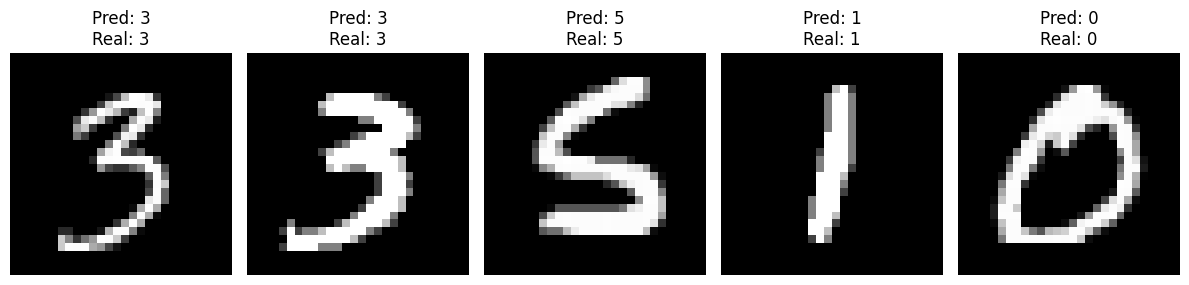

In [7]:
import matplotlib.pyplot as plt

indices = np.random.randint(0, len(x_test), 5)

for idx in indices:
    imagen = x_test[idx]
    probs = forward_pass(imagen)
    pred = np.argmax(probs)
    real = y_test[idx]

    print(f"Real: {real} | Predicción: {pred} | Confianza: {probs[pred]:.4f} | {'✅' if pred == real else '❌'}")

plt.figure(figsize=(12, 3))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    probs = forward_pass(x_test[idx])
    pred = np.argmax(probs)
    plt.title(f"Pred: {pred}\nReal: {y_test[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Imagen guardada | Dígito real: 4


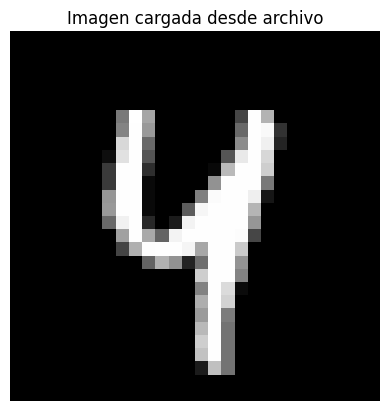

Predicción: 4 | Confianza: 0.9985


In [8]:
from PIL import Image

idx = 42
imagen_pil = Image.fromarray((x_test[idx] * 255).astype(np.uint8))
imagen_pil.save("prueba.png")
print(f"Imagen guardada | Dígito real: {y_test[idx]}")

img = Image.open("prueba.png").convert('L')
img = img.resize((28, 28))
img_array = np.array(img).astype(np.float32) / 255.0

plt.imshow(img_array, cmap='gray')
plt.title(f"Imagen cargada desde archivo")
plt.axis('off')
plt.show()

probs = forward_pass(img_array)
pred = np.argmax(probs)
print(f"Predicción: {pred} | Confianza: {probs[pred]:.4f}")

Saving 5.png to 5.png


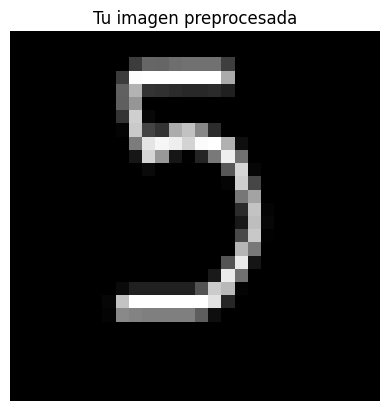

Predicción: 2 | Confianza: 0.7499
Probabilidades por dígito: [1.000e-04 1.000e-04 7.499e-01 2.490e-01 0.000e+00 6.000e-04 2.000e-04
 2.000e-04 0.000e+00 0.000e+00]


In [10]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
img_name = list(uploaded.keys())[0]

img = Image.open(img_name).convert('L')
img = img.resize((28, 28))
img_array = np.array(img).astype(np.float32) / 255.0

plt.imshow(img_array, cmap='gray')
plt.title("Tu imagen preprocesada")
plt.axis('off')
plt.show()

probs = forward_pass(img_array)
pred = np.argmax(probs)
print(f"Predicción: {pred} | Confianza: {probs[pred]:.4f}")
print(f"Probabilidades por dígito: {np.round(probs, 4)}")